# 03 Feature Evaluation

This notebook evaluates the effectiveness of image-derived features and multisource environmental variables for webcam-based PM2.5 estimation.

The analysis investigates the predictive value of ROI image features and assesses the contribution of different feature groups through quantitative evaluation under a unified experimental framework.

**Input:** `data/processed/final_dataset.csv`

**Output:** `results/feature_evaluation/`

## Workflow Overview

1. Dataset loading and experimental setup
2. ROI image feature evaluation
3. Multisource feature evaluation
4. Performance comparison

## Setup

In [41]:
import sys
import importlib
from pathlib import Path
from scipy.stats import pearsonr, spearmanr

# Project path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
RESULTS_DIR = PROJECT_ROOT / "results" / "feature_evaluation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Data processing
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

# Project models
import src.config as config
importlib.reload(config)

import src.features.features_plots as features_plots
importlib.reload(features_plots)

import src.features.evaluation as evaluation
importlib.reload(evaluation)

# Models used for feature evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor


## 1. Dataset and Experimental Setup

Load the final processed dataset and define the experimental settings for feature evaluation.

In [24]:
# Load and prepare the final processed dataset

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"

df = pd.read_csv(DATA_PATH)

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

Dataset shape: (2581, 52)


In [ ]:
# Define target variable and feature groups

TARGET = config.TARGET
ALL_FEATURES = config.ALL_FEATURES

missing_columns = [
    column
    for column in [TARGET] + ALL_FEATURES
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}"
    )

feature_summary = pd.DataFrame(
    {
        "Feature Group": config.FEATURE_GROUPS.keys(),
        "Variables": [
            len(features)
            for features in config.FEATURE_GROUPS.values()
        ],
    }
)


In [33]:
# Configure the experimental setup

TEST_SIZE = 0.2
N_SPLITS = 5
RANDOM_STATE = 42

analysis_columns = ["time", TARGET] + ALL_FEATURES

analysis_df = (
    df[analysis_columns]
    .dropna()
    .reset_index(drop=True)
)

development_df, test_df = evaluation.random_split(
    analysis_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f"Analysis samples: {len(analysis_df)}")
print(f"Development samples: {len(development_df)}")
print(f"Test samples: {len(test_df)}")

Analysis samples: 2581
Development samples: 2064
Test samples: 517


## 2 ROI Image Feature Evaluation

This section evaluates the effectiveness of ROI-derived image features for representing PM2.5 variations.

### 2.1 Feature Distribution

This section summarizes the statistical distributions of the ROI-derived image features to provide an overview of their value ranges, variability, and potential differences in scale before subsequent analyses.

In [34]:
# Summary statistics of ROI image features

roi_summary = (
    analysis_df[config.IMAGE_FEATURES]
    .describe()
    .T[["mean","std","min","25%","50%","75%","max",]]
    .round(2)
    .rename(
        columns={
            "mean": "Mean",
            "std": "Std",
            "min": "Min",
            "25%": "Q1",
            "50%": "Median",
            "75%": "Q3",
            "max": "Max",
        }
    )
    .reset_index()
    .rename(columns={"index": "Feature"})
)

display(roi_summary)

,Feature,Mean,Std,Min,Q1,Median,Q3,Max
0,R_roi,102.71,19.64,54.22,87.20,107.81,117.49,147.48
1,G_roi,128.58,22.62,73.30,110.65,135.79,145.12,178.28
2,B_roi,153.92,23.26,98.17,135.06,160.71,171.50,204.30
3,R_std,40.76,7.76,0.00,34.91,41.34,46.11,75.69
4,G_std,45.47,10.33,0.00,35.03,47.95,53.17,77.41
5,B_std,52.60,11.00,0.00,42.11,55.50,60.76,78.77
6,S_mean,0.36,0.05,0.00,0.33,0.35,0.38,0.55
7,V_mean,0.61,0.09,0.40,0.54,0.64,0.68,0.80
8,colorfulness,38.03,9.18,0.00,31.63,36.18,43.25,69.81
9,sky_brightness,0.73,0.14,0.40,0.64,0.78,0.82,0.96


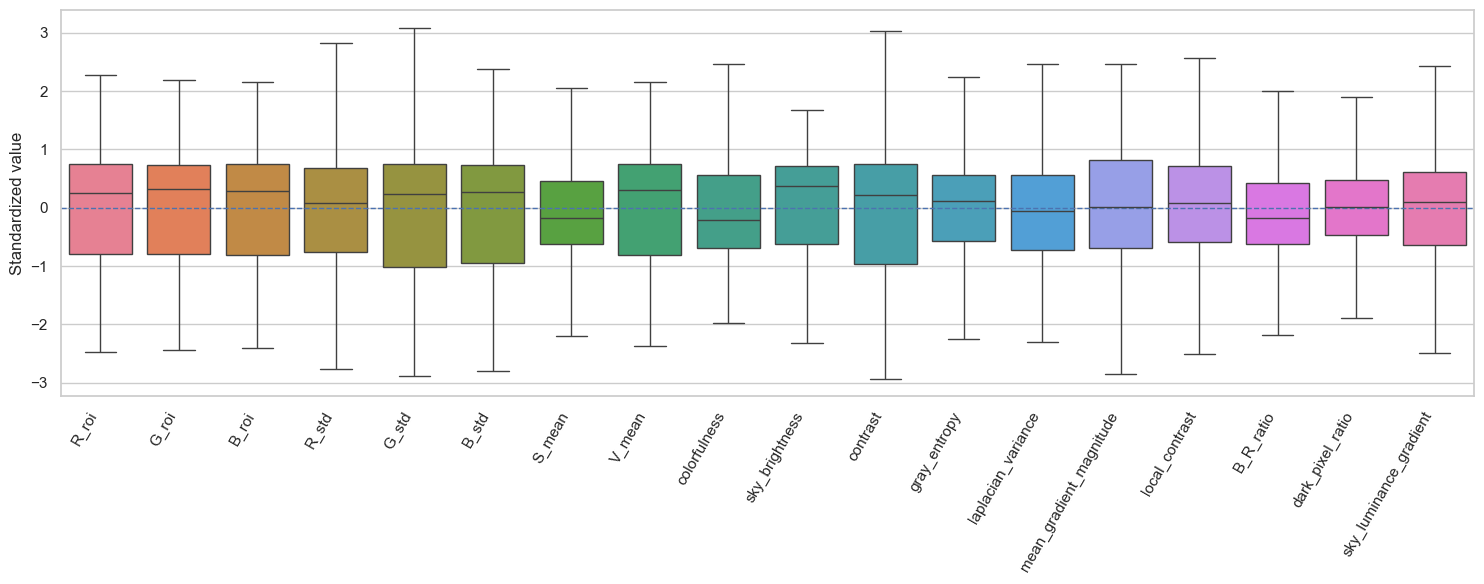

In [35]:
# Standardized boxplots of ROI image features

image_feature_data = analysis_df[config.IMAGE_FEATURES]

standardized_features = (image_feature_data - image_feature_data.mean()) / image_feature_data.std()

plt.figure(figsize=(15, 6))

sns.boxplot(data=standardized_features,showfliers=False,)

plt.axhline(y=0,linewidth=1,linestyle="--",)

plt.xlabel("")
plt.ylabel("Standardized value")
plt.xticks(rotation=60,ha="right",)

plt.tight_layout()

plt.savefig(RESULTS_DIR / "image_feature_distribution.png",dpi=300,bbox_inches="tight",)

plt.show()

### 2.2 Correlation Analysis

This section evaluates the relationships between ROI-derived image features and PM2.5 concentrations using Pearson and Spearman correlation coefficients.

In [42]:
# Pearson and Spearman correlation with PM2.5

correlation_results = []

for feature in config.IMAGE_FEATURES:

    pearson_r, pearson_p = pearsonr(
        analysis_df[feature],
        analysis_df[config.TARGET],
    )

    spearman_rho, spearman_p = spearmanr(
        analysis_df[feature],
        analysis_df[config.TARGET],
    )

    correlation_results.append(
        {
            "Feature": feature,
            "Pearson r": pearson_r,
            "Spearman ρ": spearman_rho,
            "p-value": pearson_p,
        }
    )

correlation_results = pd.DataFrame(
    correlation_results
)

display(
    correlation_results.round(
        {
            "Pearson r": 3,
            "Spearman ρ": 3,
            "p-value": 4,
        }
    )
)

,Feature,Pearson r,Spearman ρ,p-value
0,R_roi,0.101,0.139,0.0000
1,G_roi,0.076,0.129,0.0001
2,B_roi,0.065,0.121,0.0010
3,R_std,-0.259,-0.141,0.0000
4,G_std,-0.259,-0.163,0.0000
5,B_std,-0.367,-0.279,0.0000
6,S_mean,-0.234,-0.254,0.0000
7,V_mean,0.047,0.101,0.0173
8,colorfulness,-0.473,-0.456,0.0000
9,sky_brightness,-0.046,0.011,0.0205


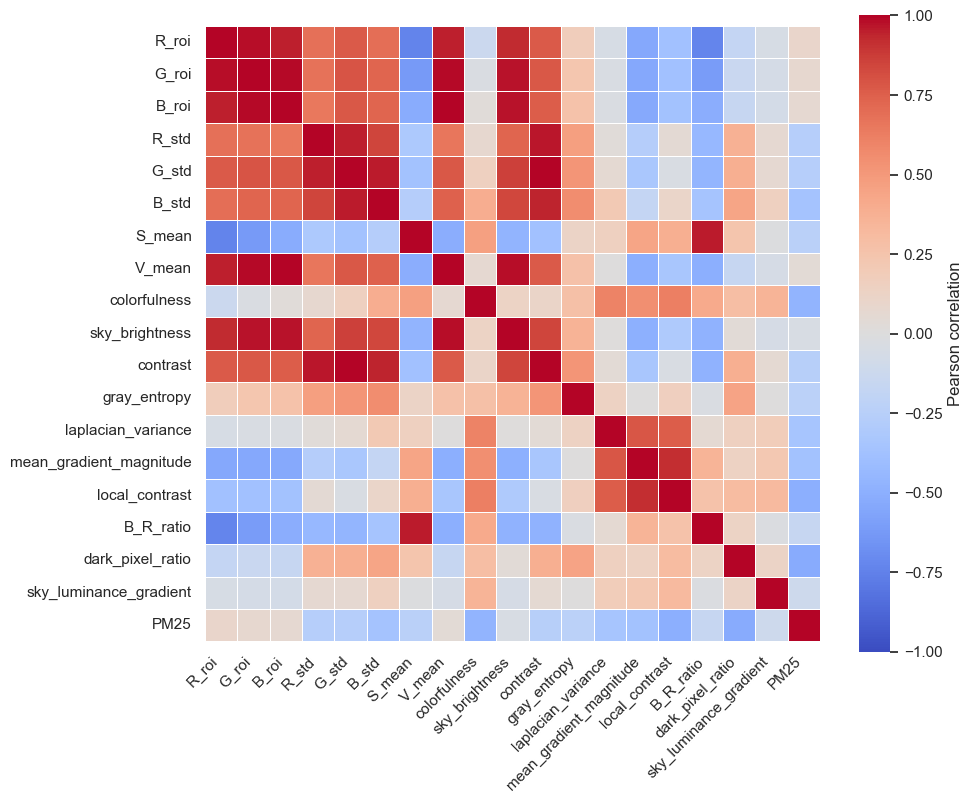

In [52]:
# Pearson correlation heatmap

correlation_matrix = (
    analysis_df[
        config.IMAGE_FEATURES + [config.TARGET]
    ]
    .corr(method="pearson")
)

plt.figure(figsize=(10, 9))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.6,
    vmin=-1,
    vmax=1,
    cbar_kws={
        "label": "Pearson correlation","shrink":0.85,
    },
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "image_feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

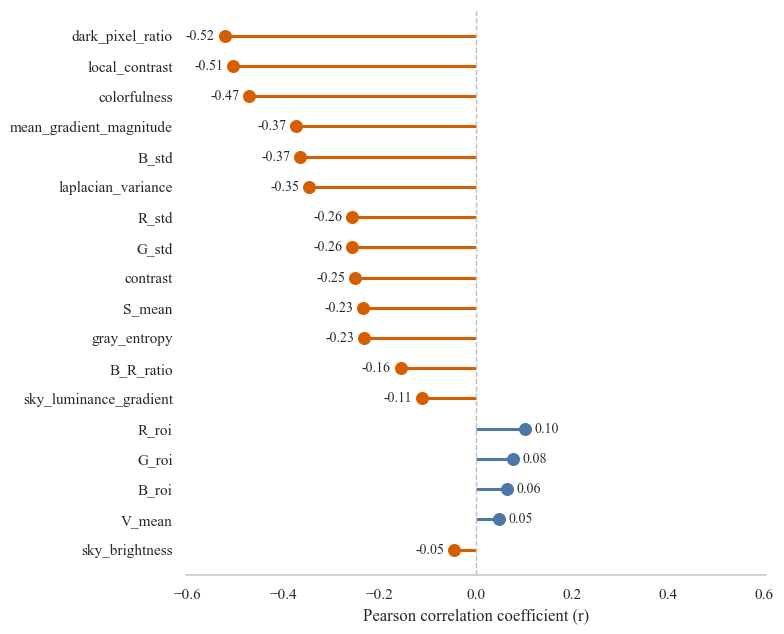

In [62]:
# Correlation ranking

import importlib
import src.features.features_plots as features_plots
features_plots = importlib.reload(features_plots)

fig = features_plots.plot_correlation_ranking(
    correlation_results=correlation_results,
    output_path=RESULTS_DIR / "image_feature_correlation_ranking.png",
)

plt.show()

### 2.3 Image Feature Group Evaluation

Compare the predictive performance of different ROI image feature groups using Ridge regression and Random Forest under the same chronological validation framework.


In [48]:
# Define ROI image feature groups

image_feature_sets = {
    "Color": config.COLOR_FEATURES,
    "Contrast": config.CONTRAST_TEXTURE_FEATURES,
    "Visibility": config.HAZE_VISIBILITY_FEATURES,
    "All": config.IMAGE_FEATURES,
}

feature_group_summary = pd.DataFrame(
    {
        "Feature Group": image_feature_sets.keys(),
        "Variables": [
            len(features)
            for features in image_feature_sets.values()
        ],
    }
)

feature_group_summary

,Feature Group,Variables
0,Color,10
1,Contrast,5
2,Visibility,3
3,All,18


In [49]:
# Models used only for image feature-group evaluation

ridge_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]
)

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

# Evaluate image feature groups

models = {
    "Ridge": ridge_model,
    "Random Forest": random_forest_model,
}

image_group_results = []

for model_name, model in models.items():
    for feature_set_name, feature_list in image_feature_sets.items():

        summary, _, _, _ = evaluation.evaluate_feature_set(
            model=model,
            model_name=model_name,
            feature_set_name=feature_set_name,
            feature_list=feature_list,
            development_df=development_df,
            test_df=test_df,
            target=TARGET,
            n_splits=N_SPLITS,
            random_state=RANDOM_STATE,
        )

        image_group_results.append(summary)

image_group_results = pd.concat(
    image_group_results,
    ignore_index=True,
)

display(
    image_group_results.round(
        {
            "CV MAE": 3,
            "CV MAE Std": 3,
            "CV RMSE": 3,
            "CV RMSE Std": 3,
            "CV R2": 3,
            "CV R2 Std": 3,
            "Test MAE": 3,
            "Test RMSE": 3,
            "Test R2": 3,
        }
    )
)

,Model,Feature Set,Variables,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std,Test MAE,Test RMSE,Test R2
0,Ridge,Color,10,5.877,0.036,8.308,0.212,0.427,0.021,5.954,8.456,0.392
1,Ridge,Contrast,5,6.340,0.105,8.956,0.300,0.334,0.033,6.577,9.090,0.297
2,Ridge,Visibility,3,6.797,0.178,9.279,0.320,0.285,0.035,6.839,9.306,0.263
3,Ridge,All,18,5.565,0.091,7.806,0.120,0.493,0.037,5.730,7.892,0.470
4,Random Forest,Color,10,5.200,0.242,7.432,0.320,0.541,0.041,4.894,6.869,0.599
5,Random Forest,Contrast,5,5.208,0.131,7.520,0.269,0.530,0.037,5.255,7.577,0.512
6,Random Forest,Visibility,3,5.401,0.189,7.809,0.256,0.493,0.035,5.787,8.341,0.408
7,Random Forest,All,18,4.721,0.182,6.831,0.129,0.612,0.024,4.740,6.699,0.618


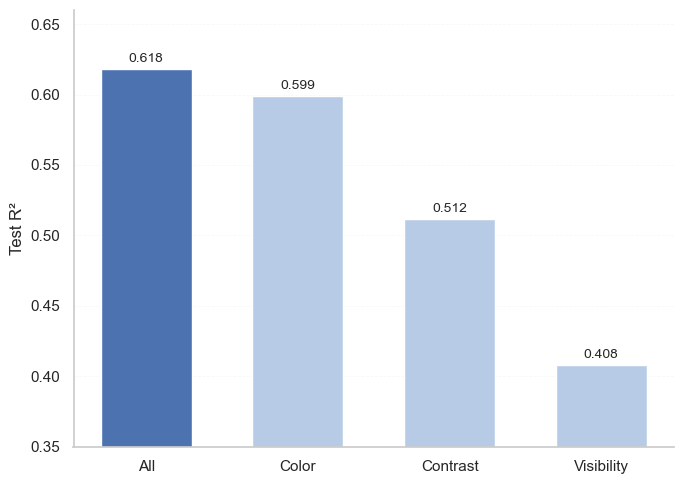

In [284]:
# Compare Test R² of image feature groups (Random Forest)

rf_results = (
    image_group_results[
        image_group_results["Model"] == "Random Forest"
    ]
    .sort_values("Test R2", ascending=False)
)

# Highlight the best-performing feature group
colors = [
    "#4C72B0" if feature == "All" else "#B8CBE6"for feature in rf_results["Feature Set"]]

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    rf_results["Feature Set"],
    rf_results["Test R2"],
    color=colors,
    width=0.60,
)

# Add value labels
ax.bar_label(
    bars,
    fmt="%.3f",
    padding=3,
    fontsize=10,
)

ax.set_xlabel("")
ax.set_ylabel("Test R²", fontsize=12)

ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

# Zoom in to highlight performance differences
plt.ylim(0.35, 0.66)

# Remove all existing grid
ax.grid(False)

# Add only horizontal grid
ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    alpha=0.15,
)

ax.xaxis.grid(False)

sns.despine()

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "image_feature_group_test_r2.png",dpi=300,bbox_inches="tight",)

plt.show()

## 3. Multisource Feature Fusion Evaluation

Evaluate the contribution of different feature groups and investigate whether multisource data fusion improves PM2.5 estimation performance.

### 3.1 Feature Set Definition

Define the feature groups used for multisource performance evaluation and progressive feature fusion experiments.

In [285]:
# Define feature sets for multisource fusion evaluation

fusion_feature_sets = config.FUSION_FEATURE_SETS

feature_descriptions = {
    "Image": "ROI image features",
    "Image + ERA5": "ROI image features and ERA5 meteorological variables",
    "Image + ERA5 + ARPA": (
        "ROI image features, ERA5 variables, " "and local ARPA meteorological observations"),
    "All Features": ("Image, ERA5, ARPA, and temporal features"),
}

fusion_feature_summary = pd.DataFrame(
    {
        "Feature Set": fusion_feature_sets.keys(),
        "Description": [feature_descriptions[name]for name in fusion_feature_sets.keys()],
        "Variables": [len(features)for features in fusion_feature_sets.values()],
    }
)

fusion_feature_summary

,Feature Set,Description,Variables
0,Image,ROI image features,18
1,Image + ERA5,ROI image features and ERA5 meteorological var...,37
2,Image + ERA5 + ARPA,"ROI image features, ERA5 variables, and local ...",43
3,All Features,"Image, ERA5, ARPA, and temporal features",50


### 3.2 Incremental Feature Fusion
Evaluate how progressively adding meteorological and temporal features improves PM2.5 prediction performance.

In [286]:
# Baseline models for multisource feature fusion

ridge_model = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]
)

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

models = {
    "Ridge": ridge_model,
    "Random Forest": random_forest_model,
}

In [287]:
# Evaluate incremental feature fusion

fusion_results = []

for model_name, model in models.items():
    for feature_set_name, feature_list in config.FUSION_FEATURE_SETS.items():

        summary, _, _, _ = evaluation.evaluate_feature_set(
            model=model,
            model_name=model_name,
            feature_set_name=feature_set_name,
            feature_list=feature_list,
            development_df=development_df,
            test_df=test_df,
            target=TARGET,
            n_splits=N_SPLITS,
            random_state=RANDOM_STATE,
        )

        fusion_results.append(summary)

fusion_results = pd.concat(
    fusion_results,
    ignore_index=True,
)

display(
    fusion_results.round(
        {
            "CV MAE": 3,
            "CV MAE Std": 3,
            "CV RMSE": 3,
            "CV RMSE Std": 3,
            "CV R2": 3,
            "CV R2 Std": 3,
            "Test MAE": 3,
            "Test RMSE": 3,
            "Test R2": 3,
        }
    )
)

,Model,Feature Set,Variables,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std,Test MAE,Test RMSE,Test R2
0,Ridge,Image,18,5.565,0.091,7.806,0.120,0.493,0.037,5.730,7.892,0.470
1,Ridge,Image + ERA5,37,5.186,0.159,6.957,0.292,0.596,0.051,5.520,7.216,0.557
2,Ridge,Image + ERA5 + ARPA,43,5.193,0.155,6.948,0.275,0.597,0.049,5.558,7.185,0.561
3,Ridge,All Features,50,4.848,0.056,6.405,0.177,0.658,0.033,5.104,6.710,0.617
4,Random Forest,Image,18,4.721,0.182,6.831,0.129,0.612,0.024,4.740,6.699,0.618
5,Random Forest,Image + ERA5,37,3.798,0.243,5.195,0.545,0.774,0.045,3.944,5.320,0.759
6,Random Forest,Image + ERA5 + ARPA,43,3.784,0.244,5.187,0.542,0.775,0.044,3.909,5.295,0.762
7,Random Forest,All Features,50,3.631,0.221,4.963,0.549,0.794,0.046,3.674,4.970,0.790


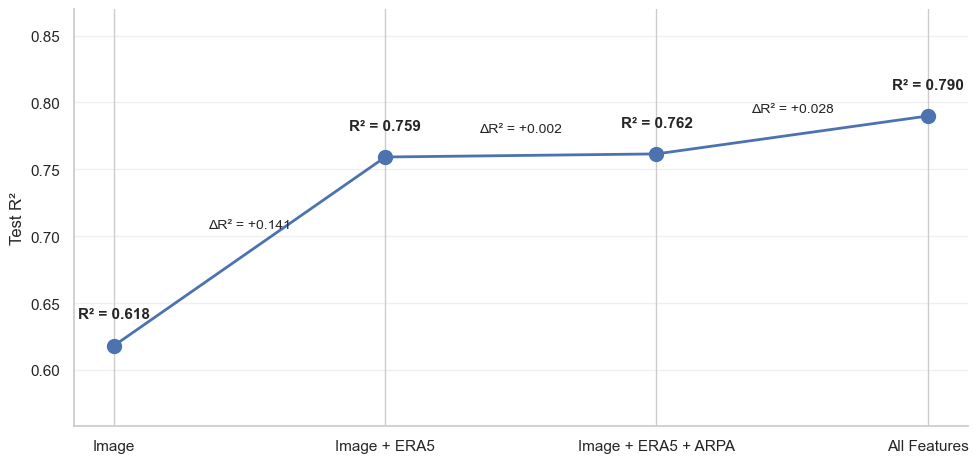

In [288]:
# Progressive multisource fusion flow based on Random Forest Test R²

rf_fusion_results = (
    fusion_results[
        fusion_results["Model"] == "Random Forest"
    ]
    .copy()
    .reset_index(drop=True)
)

rf_fusion_results["R2 Gain"] = (
    rf_fusion_results["Test R2"].diff()
)

feature_labels = [
    "Image",
    "Image + ERA5",
    "Image + ERA5 + ARPA",
    "All Features",
]

x_positions = np.arange(len(rf_fusion_results))
r2_values = rf_fusion_results["Test R2"].to_numpy()
r2_gains = rf_fusion_results["R2 Gain"].to_numpy()

fig, ax = plt.subplots(figsize=(10, 4.8))

# Connecting line
ax.plot(
    x_positions,
    r2_values,
    linewidth=2,
    marker="o",
    markersize=10,
)

# Add nodes and annotations
for i, (x, r2_value) in enumerate(
    zip(x_positions, r2_values)
):
    ax.text(
        x,
        r2_value + 0.018,
        f"R² = {r2_value:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

    if i > 0:
        midpoint_x = (
            x_positions[i - 1]
            + x_positions[i]
        ) / 2

        midpoint_y = (
            r2_values[i - 1]
            + r2_values[i]
        ) / 2

        ax.text(
            midpoint_x,
            midpoint_y + 0.015,
            f"ΔR² = +{r2_gains[i]:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
        )

# X-axis labels
ax.set_xticks(x_positions)
ax.set_xticklabels(
    feature_labels,
    fontsize=11,
)

ax.set_ylabel(
    "Test R²",
    fontsize=12,
)

ax.set_xlabel("")

ax.set_ylim(
    min(r2_values) - 0.06,
    max(r2_values) + 0.08,
)

ax.grid(
    axis="y",
    alpha=0.3,
)

sns.despine()

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "progressive_fusion_flow.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()